# CSEM exercise

Created by Michele Paulatto, Imperial College London

https://github.com/michpaulatto/AppliedGeophysicsExercises


Version 1.0 - 05.02.2025

This exercise is distributed under a [GNU GPL 3.0 license](https://www.gnu.org/licenses/gpl-3.0.en.html).

![](https://www.gnu.org/graphics/gplv3-with-text-136x68.png)

Developed for [Google Colab](https://colab.research.google.com/)



#Environment setup

We need to set up the Python environment before we start. If running the exercise on your local machine the setup would have to be modified. We need to install Anaconda (https://www.anaconda.com/) and use it to install SegyIO. Some of the operations in the setup are a bit advanced and are beyond the scope of this exercise. So just run the following two code cells and move on. This may take a couple of minutes so be patient. If running this Notebook on Google Colab for the first time you may get a warning that the Notebook was not authored by Google, click OK and continue.

In [253]:
!pip install -q "condacolab==0.1.3"
import condacolab
condacolab.install_from_url("https://github.com/jaimergp/miniforge/releases/download/24.11.2-1_colab/Miniforge3-colab-24.11.2-1_colab-Linux-x86_64.sh")

✨🍰✨ Everything looks OK!


In [ ]:
import condacolab
condacolab.check()
!mamba install -c prisae empymod --yes >& log.out
print("modules installed")

✨🍰✨ Everything looks OK!
modules installed


# Import modules and setup environment
Here we import the Python modules that we need for the exercise.



In [254]:
import empymod
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('ggplot')

# Geometry setup
Below we define the model geometry. We consider a layered 1D model. Each layer is defined by its bottom boundary and resistivity. The last layer does not have a bottom.

First we define the background model and analyse its EM response

Text(0.5, 0, 'Resistivity ρₕ (Ωm)')

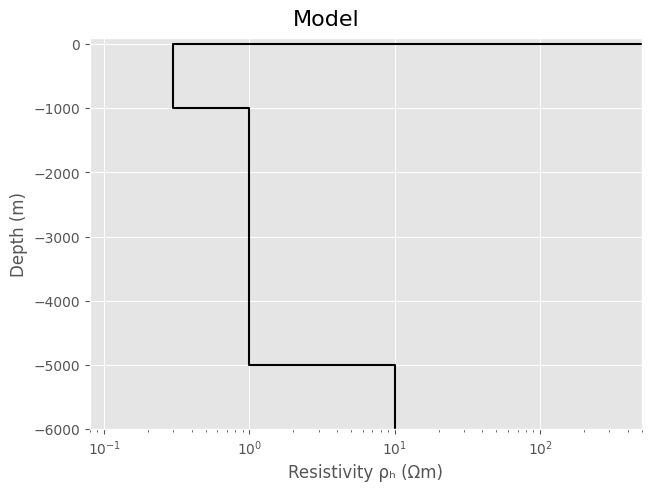

In [255]:
depth = [0, -1000, -2000, -2100, -5000]  # Layer boundaries
res_bg = [2e14, 0.3, 1, 1, 1, 10]    # Background resistivities in Ohm
p_depth = np.repeat(np.r_[100, depth, 2*depth[-1]], 2)[1:-1]

# Create figure
fig, ax1 = plt.subplots(1, 1, constrained_layout=True, sharey=True)
fig.suptitle("Model", fontsize=16)

# Plot Resistivities
ax1.semilogx(np.repeat(res_bg, 2), p_depth, 'k')
ax1.set_xlim([0.08, 500])
ax1.set_ylim([-6000, 100])
ax1.set_ylabel('Depth (m)')
ax1.set_xlabel('Resistivity ρₕ (Ωm)')

Below we calculate the Em response and plot the decay of the EM field with offset

In [256]:
# Spatial parameters
srcz = -950                   # Source depth
recz = -1000                   # Receiver depth
recx = np.arange(5, 101)*150  # Receiver offsets in x-direction
recy = np.zeros(96)           # Receiver offsets in y-direction

# General input
inpdat = {
    'rec': [recx, recy, recz, 0, 0],
    'depth': depth,
    'freqtime': 0.25,                 # 1 Hz
    'htarg': {'pts_per_dec': -1},  # Faster computation
    'verb': 2,                     # Verbosity
}

# Dipole Source [x, y, z, azm, dip]
inpdat['src'] = [0, 0, srcz, 0, 0]
dip_bg = empymod.bipole(res=res_bg, **inpdat)


:: empymod END; runtime = 0:00:00.008677 :: 1 kernel call(s)



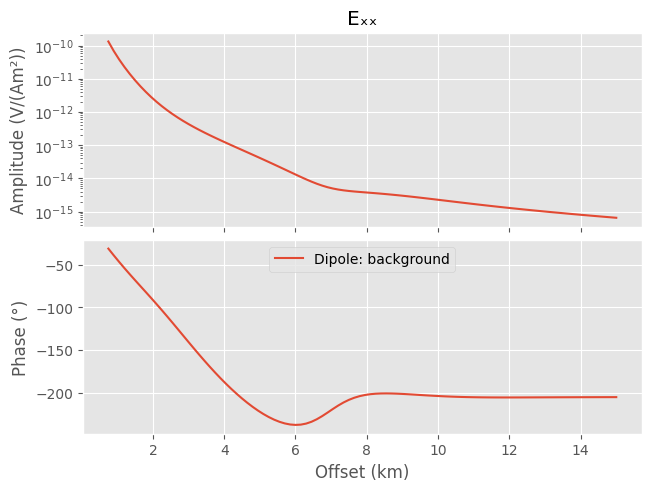

In [257]:
fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True, constrained_layout=True)

ax1.set_title("Eₓₓ")

# Plot Amplitude
ax1.semilogy(recx/1000, dip_bg.amp())
ax1.set_ylabel('Amplitude (V/(Am²))')

# Plot Phase
ax2.plot(recx/1000, dip_bg.pha(deg=True), label='Dipole: background')
ax2.set_xlabel('Offset (km)')
ax2.set_ylabel('Phase (°)')
ax2.legend(ncols=2, loc='upper center')

Now consider a model with a gas reservoir, which has a resistivity of 100 Ohm m

Text(0.5, 0, 'Resistivity ρₕ (Ωm)')

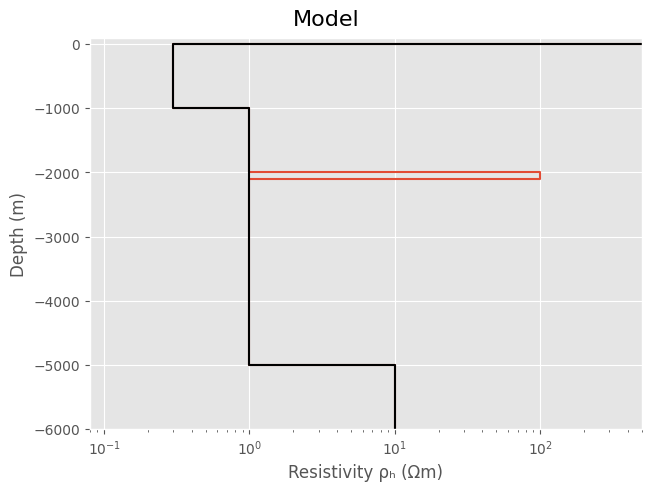

In [258]:
res_tg = [2e14, 0.3, 1, 100, 1, 10]    # Background resistivities in Ohm

# Create figure
fig, ax1 = plt.subplots(1, 1, constrained_layout=True, sharey=True)
fig.suptitle("Model", fontsize=16)

# Plot Resistivities
ax1.semilogx(np.repeat(res_tg, 2), p_depth, 'C0')
ax1.semilogx(np.repeat(res_bg, 2), p_depth, 'k')
ax1.set_xlim([0.08, 500])
ax1.set_ylim([-6000, 100])
ax1.set_ylabel('Depth (m)')
ax1.set_xlabel('Resistivity ρₕ (Ωm)')



Run new calculation

In [259]:

dip_tg = empymod.bipole(res=res_tg, **inpdat)



:: empymod END; runtime = 0:00:00.005653 :: 1 kernel call(s)



Plot and compare with the background model

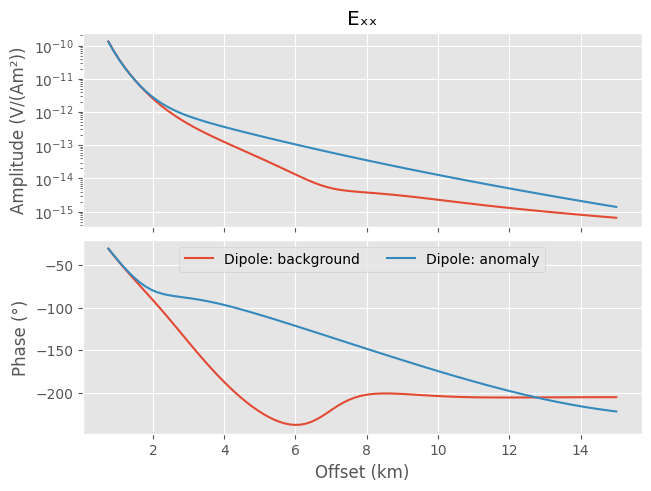

In [260]:
fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True, constrained_layout=True)

ax1.set_title("Eₓₓ")

# Plot Amplitude
ax1.semilogy(recx/1000, dip_bg.amp())
ax1.semilogy(recx/1000, dip_tg.amp())
ax1.set_ylabel('Amplitude (V/(Am²))')

# Plot Phase
ax2.plot(recx/1000, dip_bg.pha(deg=True), label='Dipole: background')
ax2.plot(recx/1000, dip_tg.pha(deg=True), label='Dipole: anomaly')
ax2.set_xlabel('Offset (km)')
ax2.set_ylabel('Phase (°)')
ax2.legend(ncols=2, loc='upper center')

Text(0, 0.5, 'Phase anomaly (°)')

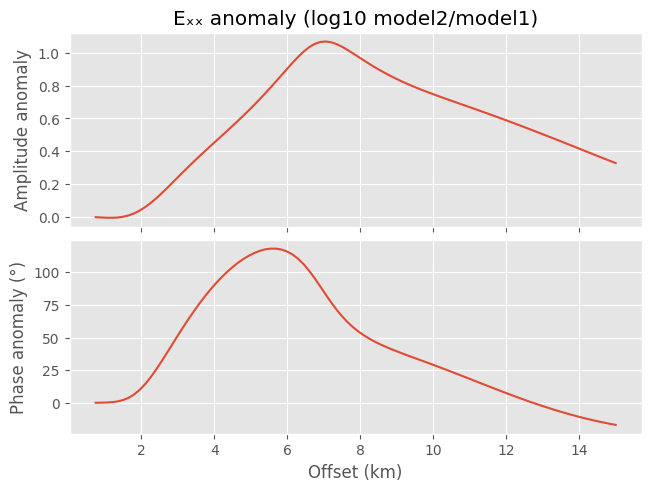

In [261]:
fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True, constrained_layout=True)

ax1.set_title("Eₓₓ anomaly (log10 model2/model1)")

# Plot Log Amplitude anomaly
ax1.plot(recx/1000, np.log10(dip_tg.amp()/dip_bg.amp()))
ax1.set_ylabel('Amplitude anomaly')

# Plot Phase
ax2.plot(recx/1000, dip_tg.pha(deg=True)-dip_bg.pha(deg=True))
ax2.set_xlabel('Offset (km)')
ax2.set_ylabel('Phase anomaly (°)')


# Sensitivity analysis

In [266]:
# For 33 frequencies from -1.5 to 0.5 (logspace)
freq = np.logspace(-1.5, 0.5, 33)

# General input
inpdat = {
    'rec': [recx, recy, recz, 0, 0],
    'depth': depth,
    'freqtime': freq,                 # 1 Hz
    'htarg': {'pts_per_dec': -1},  # Faster computation
    'verb': 2,                     # Verbosity
}

# Dipole Source [x, y, z, azm, dip]
inpdat['src'] = [0, 0, srcz, 0, 0]
xfEM_tg = empymod.bipole(**inpdat, res=res_tg)
xfEM_bg = empymod.bipole(**inpdat, res=res_bg)




:: empymod END; runtime = 0:00:00.198892 :: 33 kernel call(s)


:: empymod END; runtime = 0:00:00.183662 :: 33 kernel call(s)



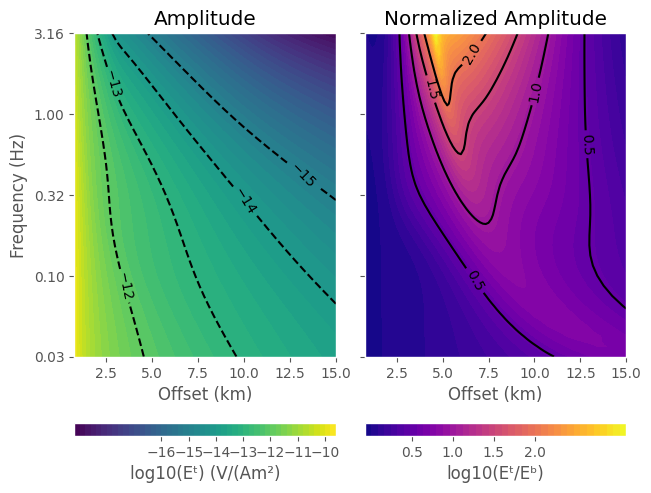

In [268]:
lfreq = np.log10(freq)
lamp = np.log10(xfEM_tg.amp())
namp = np.log10((xfEM_tg.amp()/xfEM_bg).amp())  # Target divided by background

# Create figure
fig, (ax1, ax2) = plt.subplots(
    1, 2, sharex=True, sharey=True, constrained_layout=True)

# Plot absolute (amplitude) in log10
ax1.set_title('Amplitude')
cf1 = ax1.contourf(recx/1000, lfreq, lamp, levels=50)
CS1 = ax1.contour(recx/1000, lfreq, lamp, [-15, -14, -13, -12], colors='k')
plt.clabel(CS1, inline=1, fontsize=10)
ax1.set_xlabel('Offset (km)')
ax1.set_ylabel('Frequency (Hz)')
ax1.set_yticks([-1.5, -1, -.5, 0, .5, 1.0],
               ('0.03', '0.10', '0.32', '1.00', '3.16','10.0'))
cb1 = plt.colorbar(cf1, ax=ax1, orientation='horizontal',
                   ticks=np.arange(-16., -9))
cb1.set_label('log10(Eᵗ) (V/(Am²)')

# Plot normalized
ax2.set_title('Normalized Amplitude')
cf2 = ax2.contourf(recx/1000, lfreq, namp, levels=50, cmap='plasma')
CS2 = ax2.contour(recx/1000, lfreq, namp, [0.5,1,1.5,2], colors='k')
plt.clabel(CS2, inline=1, fontsize=10)
ax2.set_ylim([lfreq[0], lfreq[-1]])
ax2.set_xlim([recx[0]/1000, recx[-1]/1000])
ax2.set_xlabel('Offset (km)')
cb2 = plt.colorbar(cf2, ax=ax2, orientation='horizontal',ticks=[0.5,1.0,1.5,2.0])
cb2.set_label('log10(Eᵗ/Eᵇ)')